# 02 — Vorverarbeitung an einem Sensor

Es wird ausschließlich ein physischer Sensor (sensorA) gezeigt. Die vier Messkanäle bleiben der Modellinput; die Abbildungen zeigen bewusst nur einen auswählbaren Kanal.


In [1]:
from pathlib import Path
import sys
HERE=Path.cwd()
if not (HERE/'day3_utils.py').exists(): HERE=HERE/'Evaluation Seminar'/'Day_03'
ROOT=HERE.parents[1]
sys.path.insert(0,str(HERE)); sys.path.insert(0,str(ROOT/'Networks'))

import numpy as np
import matplotlib.pyplot as plt
from day3_utils import load_four_sensor_splits,fit_input_zscore,apply_zscore,fit_target_zscore
splits=load_four_sensor_splits('acetone')
print({name:value['X'].shape for name,value in splits.items()})

{'train': (1090, 4, 1440, 1), 'val': (274, 4, 1440, 1), 'test': (338, 4, 1440, 1), 'test_extra': (1392, 4, 1440, 1)}


## Input Z-score

For sensor `s`, `z=(x-mean_s)/std_s`. One pair of statistics per sub-sensor preserves relative
temporal structure while preventing high-amplitude sensors from dominating optimization. Depending on
the application, per-time-point or robust median/IQR scaling can also be validâ€”but must still be fit
on training data only.

In [2]:
# Fit once on training inputs, then reuse on every split.
x_mean,x_std=fit_input_zscore(splits['train']['X'])
for name,split in splits.items(): split['X_z']=apply_zscore(split['X'],x_mean,x_std)
print('stored mean/std shapes:',x_mean.shape,x_std.shape)
print('scaled training mean/std:',splits['train']['X_z'].mean(axis=(0,2),dtype=np.float64).ravel(),splits['train']['X_z'].std(axis=(0,2),dtype=np.float64).ravel())

stored mean/std shapes: (1, 4, 1, 1) (1, 4, 1, 1)
scaled training mean/std: [-3.79114620e-08 -2.64882685e-07 -1.42820789e-07 -4.01844297e-08] [1.00000006 0.99999997 1.00000004 1.00000004]


## Optional output Z-score

Targets can also span large or very different ranges. Training on standardized targets makes MSE and
gradients numerically easier to handle, especially for multi-output regression. Always invert the
transformation for ppb metrics: `prediction_ppb = prediction_z * y_std + y_mean`. Store target
statistics with the model.

In [3]:
y_mean,y_std=fit_target_zscore(splits['train']['y'])
for split in splits.values(): split['y_z']=(split['y']-y_mean)/y_std
print('target mean/std:',y_mean,y_std)
print('inverse-transform check:',splits['val']['y_z'][0]*y_std+y_mean,splits['val']['y'][0])

target mean/std: 59.80529022216797 43.645469665527344
inverse-transform check: 32.716 32.716


## Einen Kanal des Sensors nachvollziehen


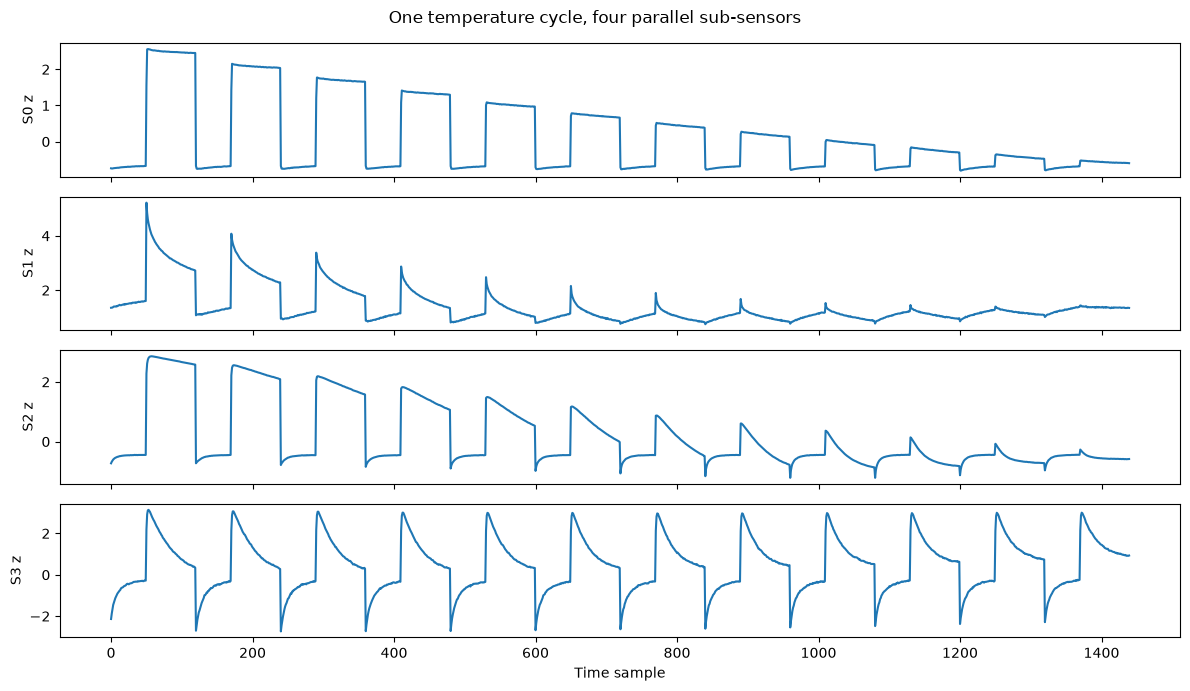

In [4]:
CHANNEL_TO_SHOW=0
sample=splits['train']['X_z'][0,CHANNEL_TO_SHOW,:,0]
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(sample)
ax.set(xlabel='Zeitindex',ylabel='standardisiertes Signal',title=f'SensorA – Kanal {CHANNEL_TO_SHOW}')
ax.grid(True,alpha=.3)
plt.show()


## Derselbe Kanal vor und nach der Skalierung


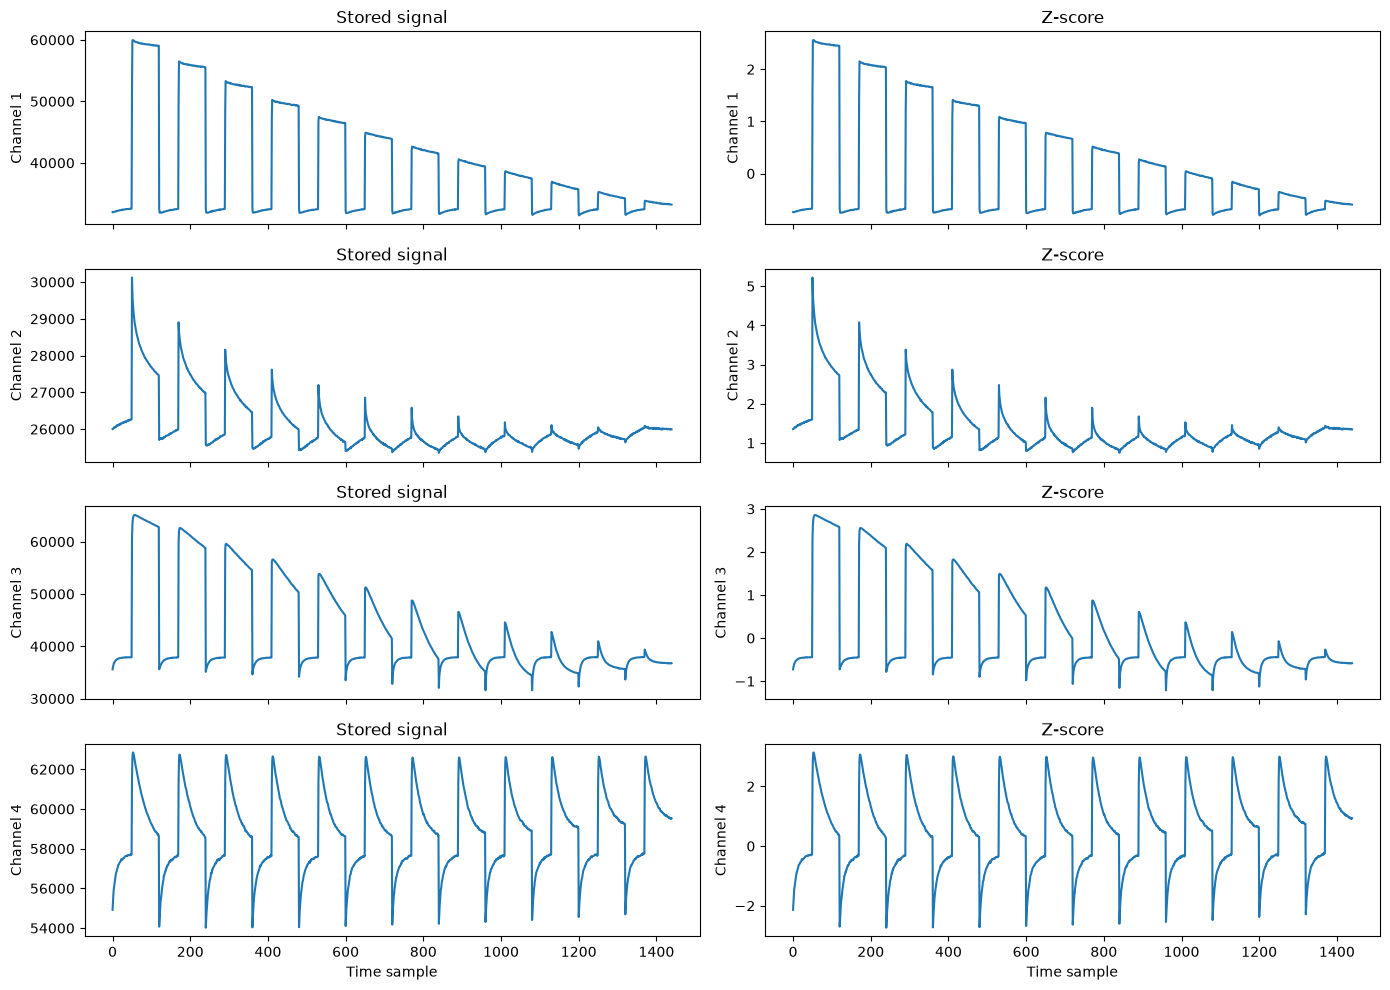

In [5]:
fig,axes=plt.subplots(1,2,figsize=(14,4),sharex=True)
for ax,key,title in zip(axes,['X','X_z'],['Rohsignal','Z-standardisiert']):
    ax.plot(splits['train'][key][0,CHANNEL_TO_SHOW,:,0])
    ax.set(title=title,xlabel='Zeitindex'); ax.grid(True,alpha=.3)
axes[0].set_ylabel('Signal')
plt.show()


## Verteilung und Zeitstruktur dieses Kanals


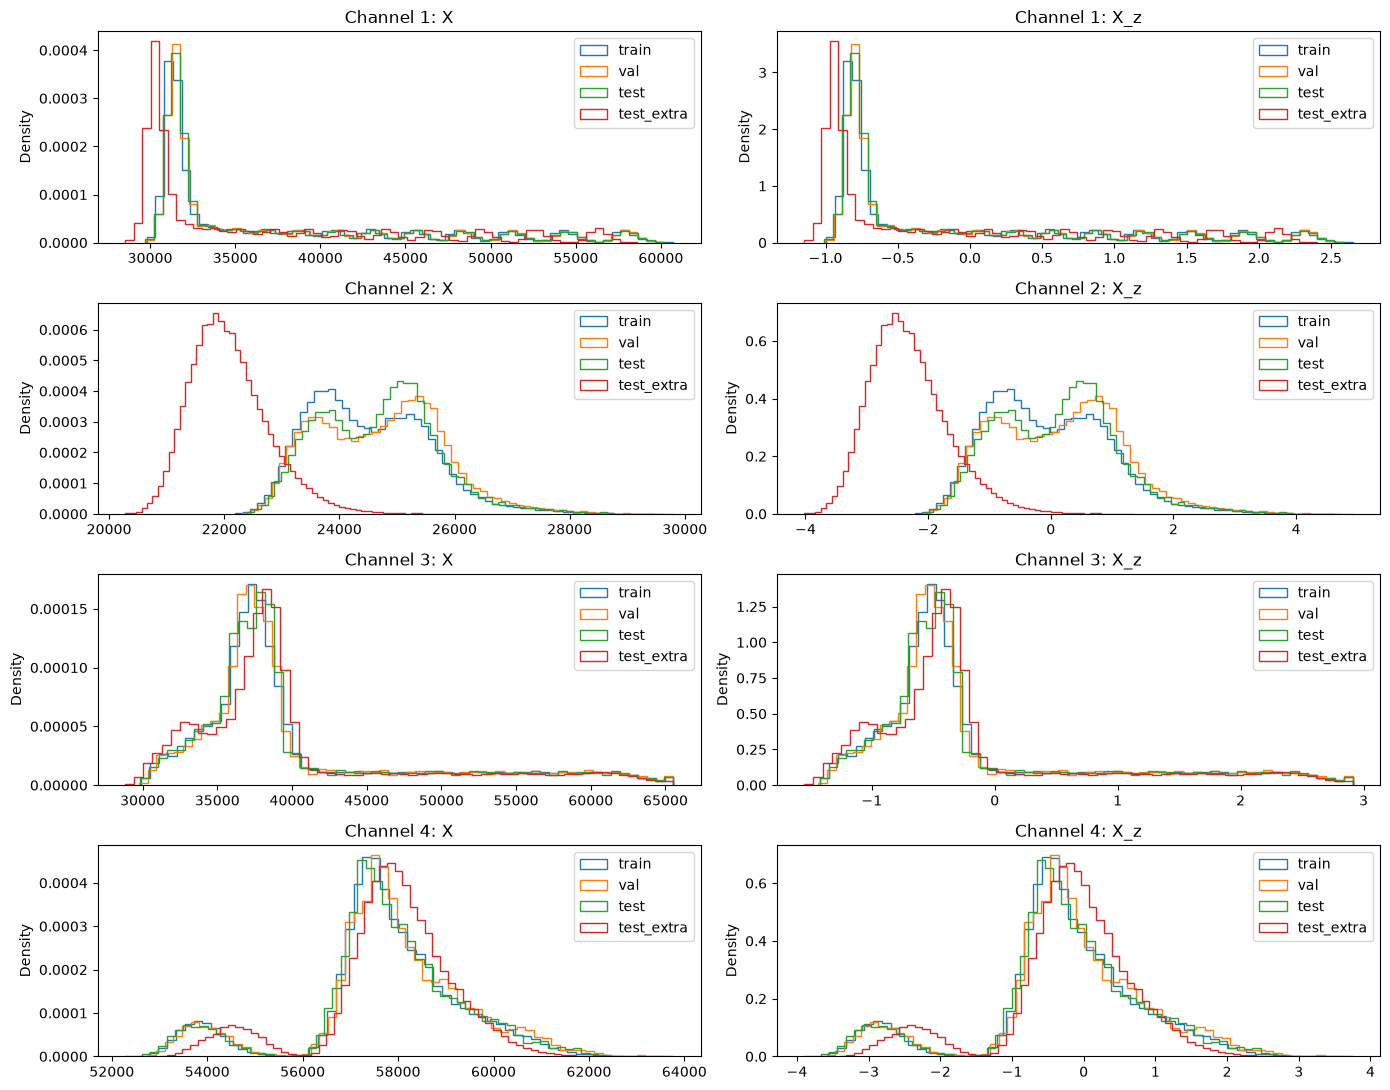

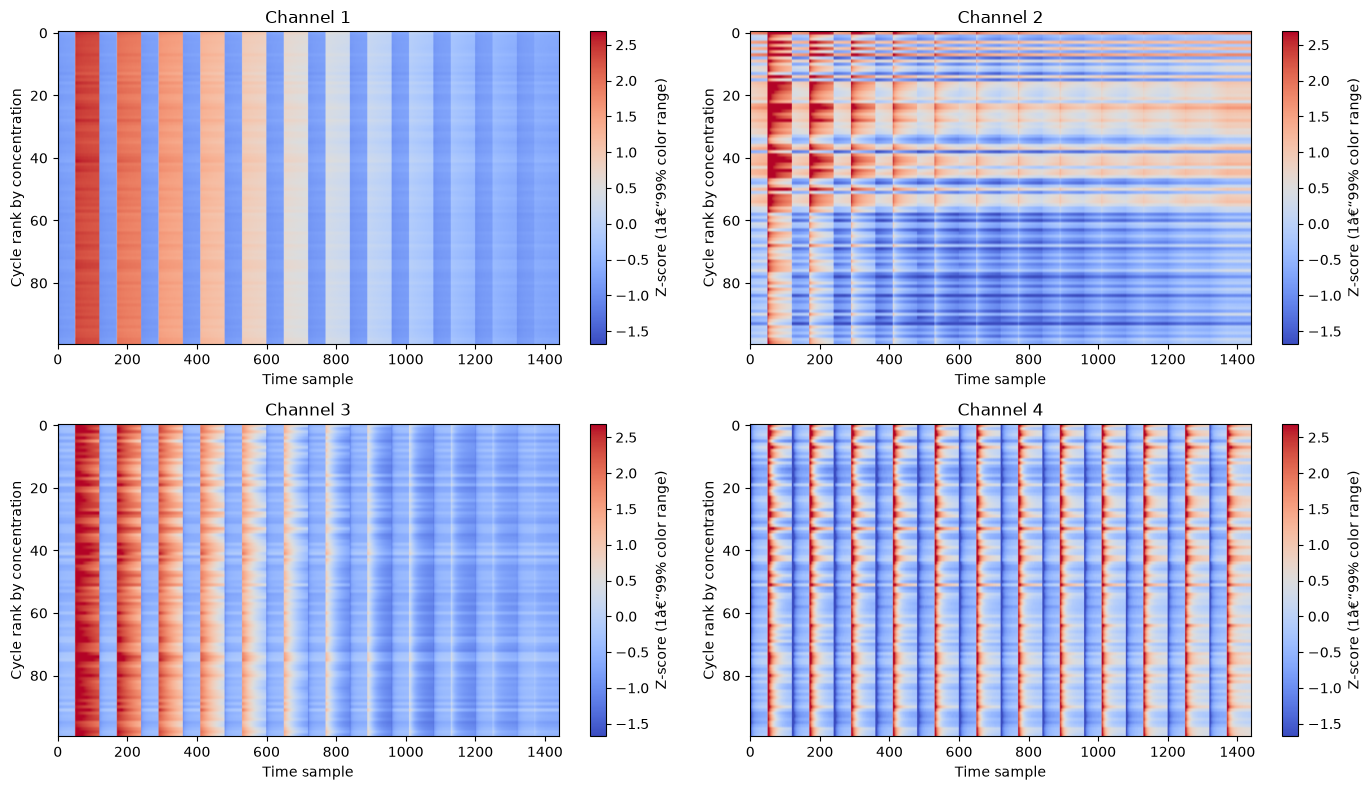

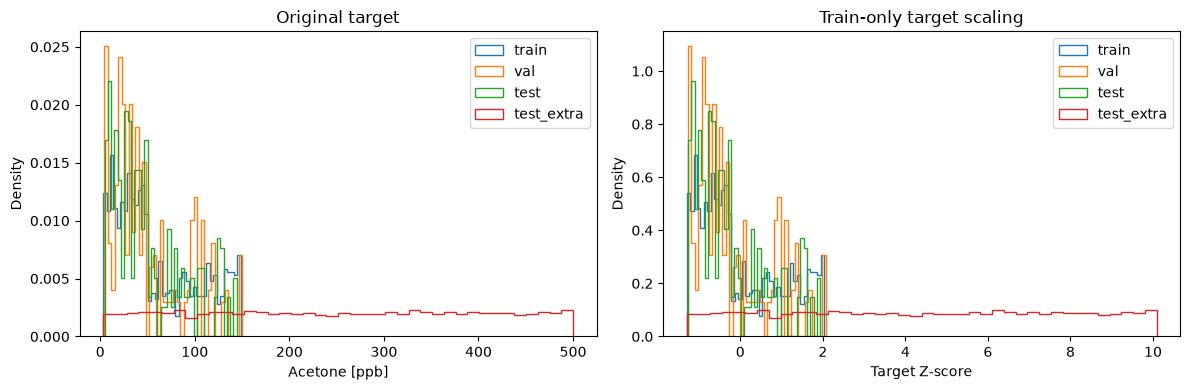

In [6]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
values=splits['train']['X_z'][:,CHANNEL_TO_SHOW,::12,0]
axes[0].hist(values.ravel(),bins=60); axes[0].set(title='Werteverteilung',xlabel='z',ylabel='Anzahl')
order=np.argsort(splits['train']['y'])
im=axes[1].imshow(splits['train']['X_z'][order,CHANNEL_TO_SHOW,::12,0],aspect='auto',cmap='viridis')
axes[1].set(title='Zyklen nach Konzentration sortiert',xlabel='Zeit (×12)',ylabel='Zyklus')
fig.colorbar(im,ax=axes[1],label='z')
for ax in axes: ax.grid(True,alpha=.2)
plt.show()
